In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

In [2]:
data = pd.read_csv("/home/edu/Area_de_Trabalho/Projs/links/data/movies/testes/probs4.csv",header= None)
data2 = pd.read_csv("/home/edu/Area_de_Trabalho/Projs/links/data/movies/testes/probs7.csv",header= None)
original = pd.read_csv("/home/edu/Area_de_Trabalho/Projs/links/data/movies/testes/grafo_0.csv",header = None)

In [3]:
data

,0,1,2,3,4
0,930,139106,0.073171,139412,139629
1,930,139412,0.073171,139412,139629
2,930,139523,0.121951,139412,139629
3,930,139526,0.121951,139412,139629
4,930,139529,0.121951,139412,139629
...,...,...,...,...,...
123831658,930,209058,0.000000,142513,142518
123831659,930,213409,0.000000,142513,142518
123831660,930,221082,0.000000,142513,142518
123831661,930,146894,0.000000,142513,142518


In [4]:
values = []
for i,j in data.groupby(1):
    
    values.append([j[0].values[0],j[1].values[0],j[2].values])

values2 = []
for i,j in data2.groupby(1):
    
    values2.append([j[0].values[0],j[1].values[0],j[2].values])

In [5]:
df = pd.DataFrame(values)
df2 = pd.DataFrame(values2)
pares_data = set(zip(data2[0], data2[1]))
pares_original = set(zip(original[1], original[0]))

pares_validos = pares_data & pares_original   # interseção
df2["label"] = (
    list(zip(df2[0], df2[1]))
)

df2[4] = (
    list(zip(df2[0], df2[1]))
)


df2["label"] = df2["label"].isin(pares_validos).astype(int)

In [6]:
df2

,0,1,2,label,4
0,930,138494,"[0.0238095, 0.0192308, 0.0294118, 0.03125, 0.0...",1,"(930, 138494)"
1,930,138495,"[0.119048, 0.0961538, 0.117647, 0.09375, 0.2, ...",0,"(930, 138495)"
2,930,138496,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"(930, 138496)"
3,930,138497,"[0.0238095, 0.0192308, 0.0294118, 0.03125, 0.1...",1,"(930, 138497)"
4,930,138498,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"(930, 138498)"
...,...,...,...,...,...
7767,930,257490,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"(930, 257490)"
7768,930,259128,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"(930, 259128)"
7769,930,264409,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"(930, 264409)"
7770,930,268200,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,"(930, 268200)"


In [7]:
X_train, X_test, y_train, y_test = train_test_split([i for i in df2[2]],df2["label"], test_size=0.4, random_state=42)


In [8]:
X_train

[array([0., 0., 0., ..., 0., 0., 0.], shape=(15931,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(15931,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(15931,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(15931,)),
 array([0.547619, 0.519231, 0.558824, ..., 0.857143, 0.555556, 0.666667],
       shape=(15931,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(15931,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(15931,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(15931,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(15931,)),
 array([0.0714286, 0.0576923, 0.0588235, ..., 0.       , 0.       ,
        0.       ], shape=(15931,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(15931,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(15931,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(15931,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(15931,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(15931,)),
 array([0., 0., 0., ..., 0., 0., 0.], shape=(15931,)),
 array([0., 0., 0., ..., 0.

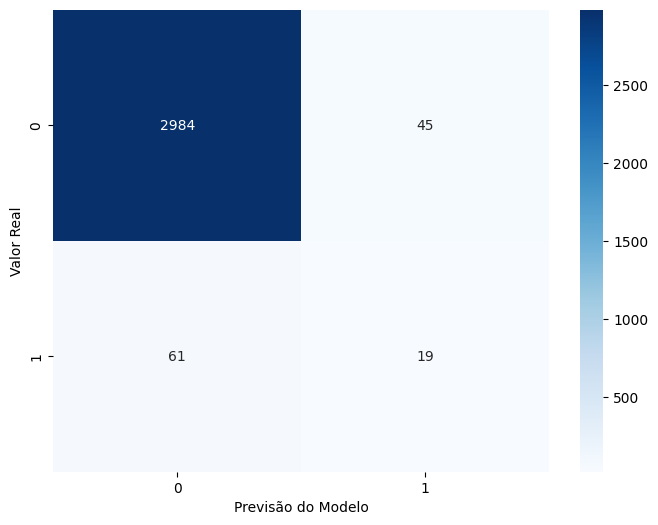

In [9]:
import seaborn as sns

modelo = KNeighborsClassifier(n_neighbors=1)
modelo.fit(X_train, y_train)
previsoes = modelo.predict(X_test)

# 3. Train the model (Assuming X_train and y_train are your data)

cm = confusion_matrix(y_test, previsoes)

# 2. Plotar de forma visual (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
# plt.title('Matriz de Confusão - Classificação de Flores')
plt.show()